# Notebook 2: Data Preprocessing and Windowing
**Objective:** To clean the raw time-series data, scale the numerical features, and engineer the 3D sliding time-windows required for the LSTM deep learning model.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

print("Libraries loaded.")

# Load the LBNL dataset
file_path = '../data/raw/MZVAV-1.csv'
df = pd.read_csv(file_path, parse_dates=['Datetime'], index_col='Datetime')

print(f"Dataset Shape: {df.shape}")

Libraries loaded.
Dataset Shape: (272160, 17)


In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
df_clean = df.ffill()

missing_after = df_clean.isnull().sum().sum()
print(f"Total missing values after Forward-Fill: {missing_after}")

Total missing values after Forward-Fill: 0


In [4]:
target_col = 'Fault Detection Ground Truth'
y = df_clean[target_col]
X = df_clean.drop(columns=[target_col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Scaling complete. First 5 rows of standardized features:")
display(X_scaled_df.head())

Scaling complete. First 5 rows of standardized features:


,AHU: Supply Air Temperature,AHU: Supply Air Temperature Set Point,AHU: Outdoor Air Temperature,AHU: Mixed Air Temperature,AHU: Return Air Temperature,AHU: Supply Air Fan Status,AHU: Return Air Fan Status,AHU: Supply Air Fan Speed Control Signal,AHU: Return Air Fan Speed Control Signal,AHU: Outdoor Air Damper Control Signal,AHU: Return Air Damper Control Signal,AHU: Cooling Coil Valve Control Signal,AHU: Heating Coil Valve Control Signal,AHU: Supply Air Duct Static Pressure Set Point,AHU: Supply Air Duct Static Pressure,Occupancy Mode Indicator
Datetime,,,,,,,,,,,,,,,,
2017-01-30 00:00:00,5.592539,7.105427e-15,-0.811613,0.404837,1.011826,-1.425666,-1.425666,-1.359687,-1.359687,-0.655845,-0.001917,-0.515743,-0.008784,6.938894e-18,-1.04299,-0.975606
2017-01-30 00:01:00,5.588612,7.105427e-15,-0.811613,0.230746,1.011826,-1.425666,-1.425666,-1.359687,-1.359687,-0.655845,-0.001917,-0.515743,-0.008784,6.938894e-18,-1.04299,-0.975606
2017-01-30 00:02:00,5.588612,7.105427e-15,-2.693583,0.230746,0.809258,-1.425666,-1.425666,-1.359687,-1.359687,-0.655845,-0.001917,-0.515743,-0.008784,6.938894e-18,-1.04299,-0.975606
2017-01-30 00:03:00,5.588612,7.105427e-15,-2.691103,0.230746,0.698521,-1.425666,-1.425666,-1.359687,-1.359687,-0.655845,-0.001917,-0.515743,-0.008784,6.938894e-18,-1.04299,-0.975606
2017-01-30 00:04:00,5.588612,7.105427e-15,-2.688622,0.230746,0.568877,-1.425666,-1.425666,-1.359687,-1.359687,-0.655845,-0.001917,-0.515743,-0.008784,6.938894e-18,-1.04299,-0.975606


In [5]:
split_index = int(len(X_scaled_df) * 0.8)

X_train = X_scaled_df.iloc[:split_index]
X_test = X_scaled_df.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Training Features Shape: (217728, 16)
Testing Features Shape: (54432, 16)


In [6]:
window_size = 60

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

print("Creating 3D sequences for the LSTM...")

X_train_lstm, y_train_lstm = create_sequences(X_train, y_train, window_size)
X_test_lstm, y_test_lstm = create_sequences(X_test, y_test, window_size)

print(f"LSTM Training Features Shape: {X_train_lstm.shape}")
print(f"LSTM Testing Features Shape: {X_test_lstm.shape}")

Creating 3D sequences for the LSTM...
LSTM Training Features Shape: (217668, 60, 16)
LSTM Testing Features Shape: (54372, 60, 16)


In [7]:
import os

processed_dir = '../data/processed/'

if not os.path.exists(processed_dir):
    os.makedirs(processed_dir)

np.save(os.path.join(processed_dir, 'X_train.npy'), X_train)
np.save(os.path.join(processed_dir, 'X_test.npy'), X_test)
np.save(os.path.join(processed_dir, 'y_train.npy'), y_train)
np.save(os.path.join(processed_dir, 'y_test.npy'), y_test)

np.save(os.path.join(processed_dir, 'X_train_lstm.npy'), X_train_lstm)
np.save(os.path.join(processed_dir, 'X_test_lstm.npy'), X_test_lstm)
np.save(os.path.join(processed_dir, 'y_train_lstm.npy'), y_train_lstm)
np.save(os.path.join(processed_dir, 'y_test_lstm.npy'), y_test_lstm)

print(f"All 8 files successfully saved to: {processed_dir}")

All 8 files successfully saved to: ../data/processed/


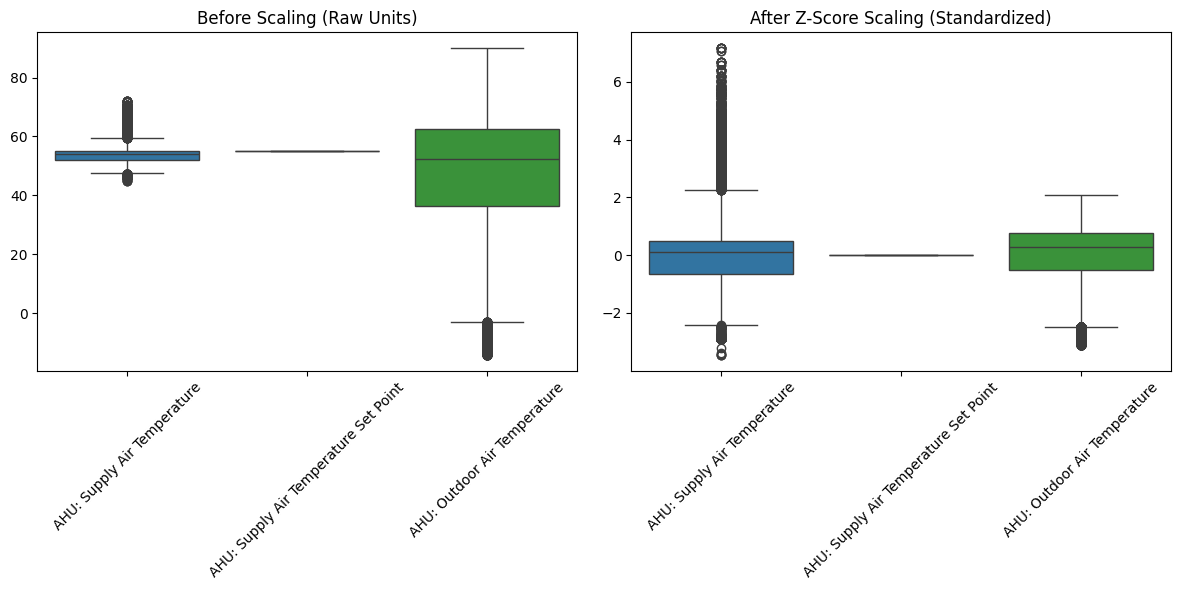

Success! Your chart is saved at: ../figures/Figure_4_4_Scaling_Comparison.png


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

os.makedirs('../figures', exist_ok=True)

raw_data_sample = df_clean.iloc[:, :3]

if isinstance(X_train, pd.DataFrame):
    scaled_data_sample = X_train.iloc[:, :3]
else:
    scaled_data_sample = pd.DataFrame(X_train, columns=df_clean.columns).iloc[:, :3]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=raw_data_sample)
plt.title("Before Scaling (Raw Units)")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=scaled_data_sample)
plt.title("After Z-Score Scaling (Standardized)")
plt.xticks(rotation=45)

plt.tight_layout()

# 4. Save the chart!
save_path = '../figures/Figure_4_4_Scaling_Comparison.png'
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Success! Your chart is saved at: {save_path}")

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import os

if 'X_train_3D' not in locals():
    print("Error: X_train_3D not found. Please run the cell where you created the 3D windows first!")
else:
    sample_window = X_train_3D[100, :, 0] 

    plt.figure(figsize=(10, 4))
    plt.plot(sample_window, color='#2ecc71', linewidth=2, marker='o', markersize=4)
    
    plt.title("Figure 4.5: Example of a 60-Minute LSTM Input Window")
    plt.xlabel("Time Steps (Minutes)")
    plt.ylabel("Standardized Sensor Value")
    plt.grid(True, linestyle='--', alpha=0.6)

    os.makedirs('../figures', exist_ok=True)
    plt.savefig('../figures/Figure_4_5_LSTM_Window_Sample.png', dpi=300)
    plt.show()

    print("Success! Figure 4.5 is saved. Your Preprocessing visuals are officially done.")

Error: X_train_3D not found. Please run the cell where you created the 3D windows first!


Building 3D windows... please wait.
Windows created! Shape: (217668, 60, 16)


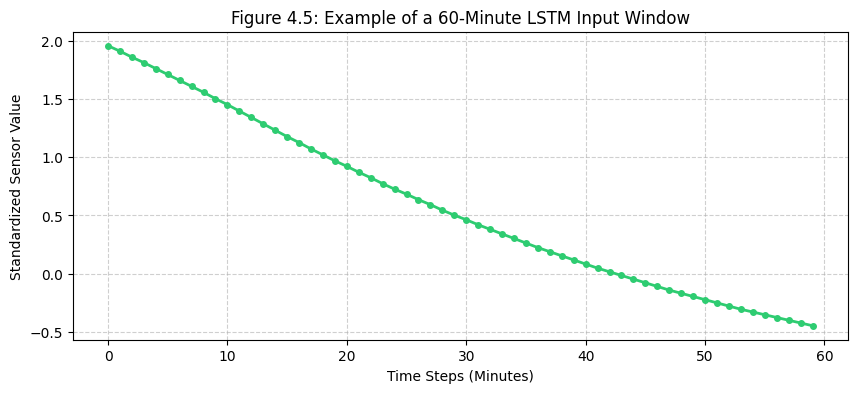

Success! Figure 4.5 saved. Preprocessing is now 100% complete.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os

WINDOW_SIZE = 60  
def create_windows(data, window_size):
    windows = []
    for i in range(len(data) - window_size):
        windows.append(data[i:i + window_size])
    return np.array(windows)

print("Building 3D windows... please wait.")
X_train_3D = create_windows(X_train.values if hasattr(X_train, 'values') else X_train, WINDOW_SIZE)
X_test_3D = create_windows(X_test.values if hasattr(X_test, 'values') else X_test, WINDOW_SIZE)

print(f"Windows created! Shape: {X_train_3D.shape}")

sample_window = X_train_3D[100, :, 0] 
plt.figure(figsize=(10, 4))
plt.plot(sample_window, color='#2ecc71', linewidth=2, marker='o', markersize=4)
plt.title("Figure 4.5: Example of a 60-Minute LSTM Input Window")
plt.xlabel("Time Steps (Minutes)")
plt.ylabel("Standardized Sensor Value")
plt.grid(True, linestyle='--', alpha=0.6)

os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/Figure_4_5_LSTM_Window_Sample.png', dpi=300)
plt.show()

print("Success! Figure 4.5 saved. Preprocessing is now 100% complete.")